# P1 — Problem Formulation & Exploratory Data Analysis

---
## 1. Problem

### Goal
Predict Turkey's hourly electricity consumption **24 hours in advance**.

In the EPİAŞ day-ahead market, energy producers must submit consumption bids for every hour of the next day, 24 hours before delivery. A poor forecast causes imbalance penalties and direct financial loss. This project builds a model to support that decision.

### What we predict
> Given everything known at time **t**, predict the consumption at time **t + 24**.

```
Input  (known now):   today's consumption, today's production(will be added), temperature, hour of day, weekday, holidays ...
Output (to predict):  consumption_mwh at the same hour tomorrow
```

### Why 24-hour ahead?
| Horizon | Difficulty | Usefulness |
|---------|-----------|------------|
| 1 hour ahead | Easy | Low — too late to adjust bids |
| **24 hours ahead** | **Medium** | **High — required for EPİAŞ market** |
| 1 week ahead | Hard | Medium — only for planning |



---
## 2. Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
import warnings
import os

warnings.filterwarnings('ignore')

os.makedirs('data', exist_ok=True)
os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})
print('Ready.')

Ready.


---
## 3. Dataset

### 3.1 Raw Data — EPİAŞ Transparency Platform
The primary dataset is `tuketim.csv`, downloaded from [EPİAŞ Transparency Platform].

It contains **hourly electricity consumption** for Turkey between January 2021 and January 2026.

| Column | Type | Example | Description |
|--------|------|---------|-------------|
| `Tarih` | string | `01.01.2021` | Date (dd.mm.yyyy) |
| `Saat` | string | `00:00` | Hour of day |
| `Tüketim Miktarı (MWh)` | string | `29.489,46` | Consumption in MWh (Turkish number format) |



### 3.2 Additional Data — Weather (to be added)
Temperature has a strong effect on electricity demand:
- **Cold weather** → more heating
- **Hot weather** → more air conditioning


### 3.3 Load Raw Data

In [7]:
DATA_FILE = './p1/tuketim.csv'

# Read everything as string first — the Turkish date format '01.01.2021' would be
# misread as a number if pandas tries to auto-detect types.
df_raw = pd.read_csv(DATA_FILE, sep=';', encoding='utf-8-sig', header=0, dtype=str)
df_raw.columns = ['date_col', 'time_col', 'consumption_mwh']

print('Raw data — first 5 rows:')
print(df_raw.head())
print(f'\nShape: {df_raw.shape}')

Raw data — first 5 rows:
     date_col time_col consumption_mwh
0  01.01.2021    00:00       29.489,46
1  01.01.2021    01:00       28.067,11
2  01.01.2021    02:00       26.527,08
3  01.01.2021    03:00       25.327,19
4  01.01.2021    04:00       24.719,72

Shape: (43848, 3)


### 3.4 Parse & Clean

In [8]:
# Combine date + time into a single datetime column
df_raw['datetime'] = pd.to_datetime(
    df_raw['date_col'].str.strip() + ' ' + df_raw['time_col'].str.strip(),
    format='%d.%m.%Y %H:%M', errors='coerce'
)

# Convert consumption: '29.489,46' → remove thousands dot → swap comma → 29489.46
df_raw['consumption_mwh'] = (
    df_raw['consumption_mwh'].astype(str).str.strip()
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

df_raw = (df_raw[['datetime', 'consumption_mwh']]
          .dropna(subset=['datetime'])
          .set_index('datetime')
          .sort_index())

# Fill any missing hours with linear interpolation
full_idx = pd.date_range(df_raw.index.min().normalize(), df_raw.index.max(), freq='h')
df = df_raw.reindex(full_idx)
missing = df['consumption_mwh'].isna().sum()
if missing > 0:
    df['consumption_mwh'] = df['consumption_mwh'].interpolate(method='linear')
df.index.name = 'datetime'

print(f'Period  : {df.index.min().date()} → {df.index.max().date()}')
print(f'Rows    : {len(df):,} hours')
print(f'Missing : {missing} hours (filled with interpolation)')
print(f'Min     : {df["consumption_mwh"].min():,.0f} MWh')
print(f'Max     : {df["consumption_mwh"].max():,.0f} MWh')
print(f'Mean    : {df["consumption_mwh"].mean():,.0f} MWh')
df.head(6)

Period  : 2021-01-01 → 2026-01-01
Rows    : 43,848 hours
Missing : 0 hours (filled with interpolation)
Min     : 19,209 MWh
Max     : 59,504 MWh
Mean    : 38,109 MWh


,consumption_mwh
datetime,
2021-01-01 00:00:00,29489.46
2021-01-01 01:00:00,28067.11
2021-01-01 02:00:00,26527.08
2021-01-01 03:00:00,25327.19
2021-01-01 04:00:00,24719.72
2021-01-01 05:00:00,24627.81


---
## 4. Raw Data Analysis

Below we look at the consumption data before adding any external features.
The goal is to understand what patterns exist naturally in the series.

### 4.1 Full Time Series

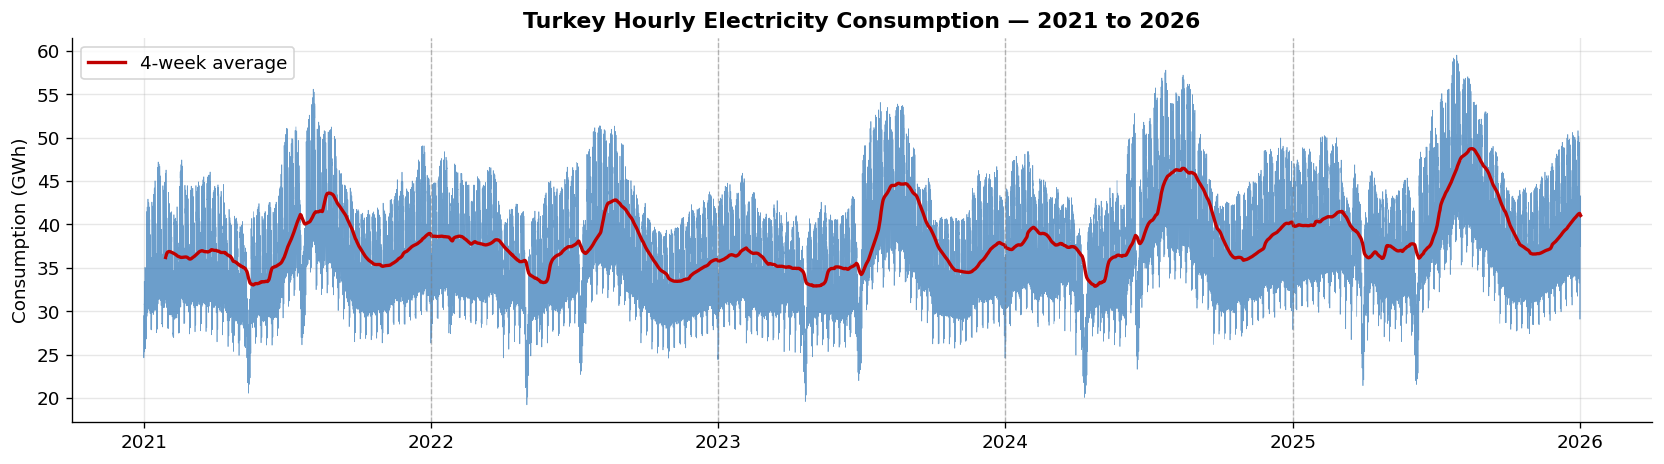

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df['consumption_mwh'] / 1000, lw=0.4, color='#2E75B6', alpha=0.7)

# Overlay a 4-week rolling average to show the seasonal trend
rolling = df['consumption_mwh'].rolling(24 * 7 * 4).mean() / 1000
ax.plot(rolling.index, rolling, lw=2, color='#C00000', label='4-week average')

for y in [2022, 2023, 2024, 2025]:
    ax.axvline(pd.Timestamp(f'{y}-01-01'), color='gray', lw=0.8, linestyle='--', alpha=0.5)

ax.set_ylabel('Consumption (GWh)')
ax.set_title('Turkey Hourly Electricity Consumption — 2021 to 2026', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend()
plt.tight_layout()
plt.savefig('figures/p1_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Seasonal Pattern — Monthly Average

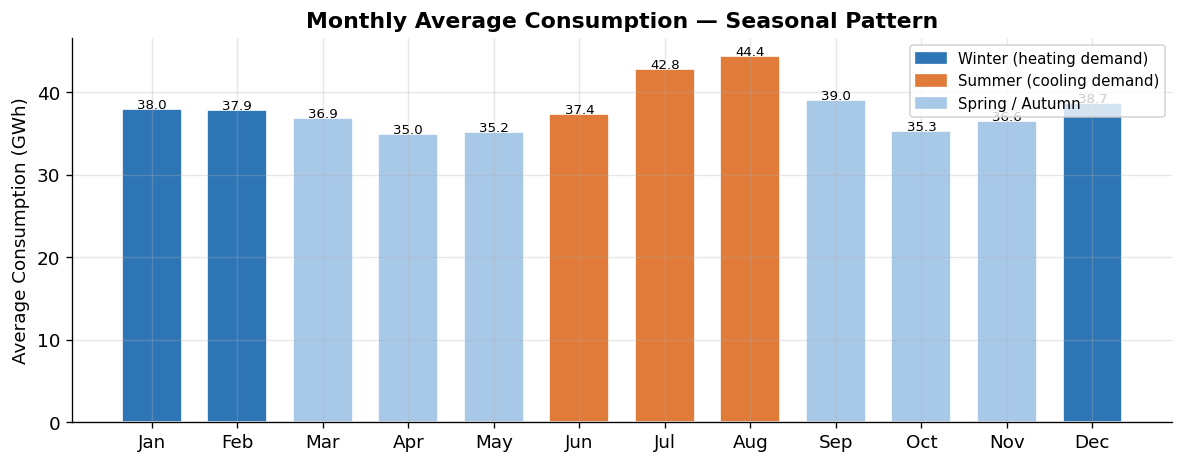

Highest consumption month: 8 — 44.4 GWh
Lowest  consumption month: 4 — 35.0 GWh


In [10]:
# Average consumption for each month across all years
df['month'] = df.index.month
df['year']  = df.index.year
monthly_avg = df.groupby('month')['consumption_mwh'].mean() / 1000

fig, ax = plt.subplots(figsize=(10, 4))

# Color: winter months blue (heating peak), summer months orange (cooling peak)
bar_colors = [
    '#2E75B6' if m in [12, 1, 2] else
    '#E07B39' if m in [6, 7, 8] else
    '#A8C8E8'
    for m in range(1, 13)
]
bars = ax.bar(range(1, 13), monthly_avg, color=bar_colors, edgecolor='white', width=0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('Average Consumption (GWh)')
ax.set_title('Monthly Average Consumption — Seasonal Pattern', fontweight='bold')

for b, v in zip(bars, monthly_avg):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05, f'{v:.1f}',
            ha='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2E75B6', label='Winter (heating demand)'),
    Patch(color='#E07B39', label='Summer (cooling demand)'),
    Patch(color='#A8C8E8', label='Spring / Autumn'),
], fontsize=9)

plt.tight_layout()
plt.savefig('figures/p1_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

print('Highest consumption month:', monthly_avg.idxmax(),
      f'— {monthly_avg.max():.1f} GWh')
print('Lowest  consumption month:', monthly_avg.idxmin(),
      f'— {monthly_avg.min():.1f} GWh')

### 4.3 Daily Pattern — Hour of Day

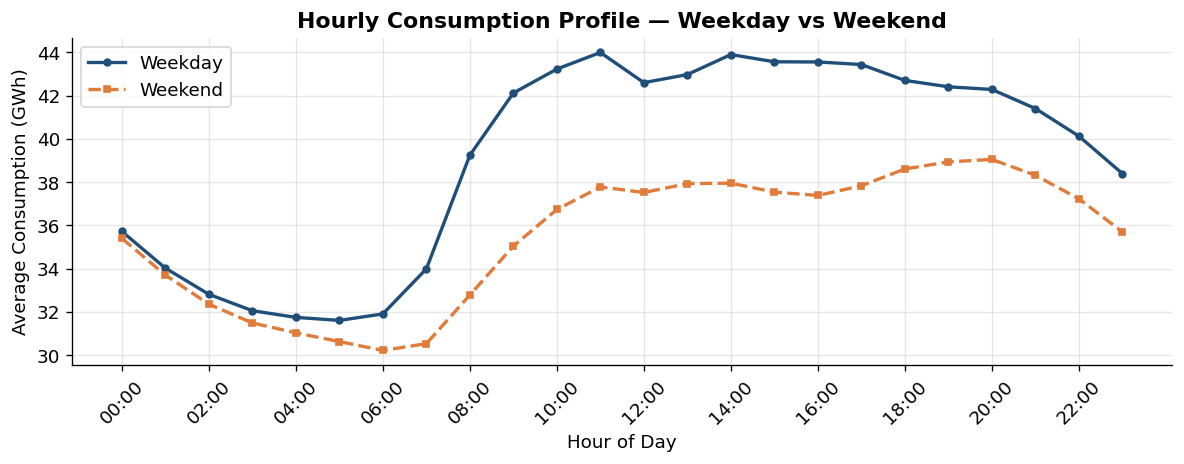

Peak hour (weekday)   : 11:00 — 44.0 GWh
Lowest hour (weekday) : 05:00 — 31.6 GWh


In [11]:
df['hour'] = df.index.hour
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)

weekday_avg = df[df['is_weekend'] == 0].groupby('hour')['consumption_mwh'].mean() / 1000
weekend_avg = df[df['is_weekend'] == 1].groupby('hour')['consumption_mwh'].mean() / 1000

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(weekday_avg, marker='o', ms=4, lw=2, color='#1F4E79', label='Weekday')
ax.plot(weekend_avg, marker='s', ms=4, lw=2, color='#E07B39', linestyle='--', label='Weekend')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Consumption (GWh)')
ax.set_title('Hourly Consumption Profile — Weekday vs Weekend', fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('figures/p1_hourly.png', dpi=150, bbox_inches='tight')
plt.show()

peak_hour = int(weekday_avg.idxmax())
trough_hour = int(weekday_avg.idxmin())
print(f'Peak hour (weekday)   : {peak_hour:02d}:00 — {weekday_avg.max():.1f} GWh')
print(f'Lowest hour (weekday) : {trough_hour:02d}:00 — {weekday_avg.min():.1f} GWh')

### 4.4 Annual Totals

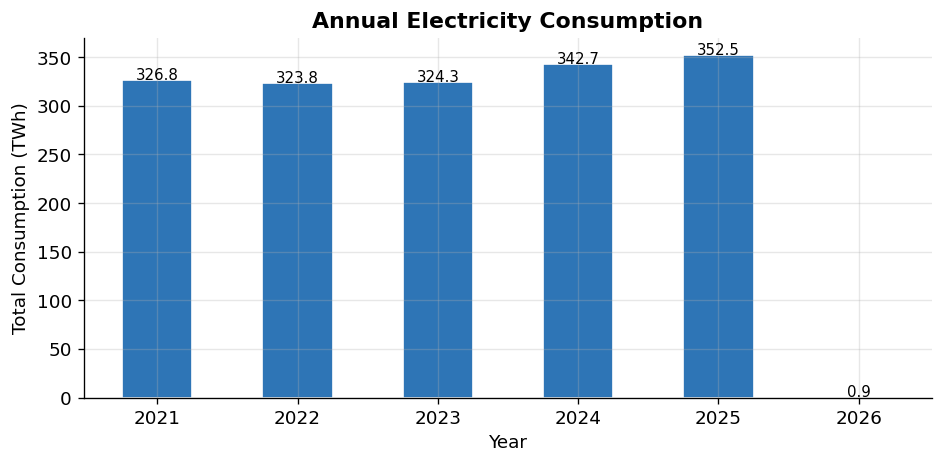

Annual totals (TWh):
  2021: 326.8 TWh
  2022: 323.8 TWh
  2023: 324.3 TWh
  2024: 342.7 TWh
  2025: 352.5 TWh
  2026: 0.9 TWh


In [12]:
annual = df.groupby('year')['consumption_mwh'].sum() / 1e6  # TWh

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(annual.index, annual.values, color='#2E75B6', edgecolor='white', width=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Total Consumption (TWh)')
ax.set_title('Annual Electricity Consumption', fontweight='bold')
for b, v in zip(bars, annual.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, f'{v:.1f}',
            ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/p1_annual.png', dpi=150, bbox_inches='tight')
plt.show()

print('Annual totals (TWh):')
for y, v in annual.items():
    print(f'  {y}: {v:.1f} TWh')

### 4.5 Key Observations

From the raw data analysis:

- **Bimodal seasonality:** consumption peaks in **winter (Jan–Feb)** due to heating and in **summer (Jul–Aug)** due to air conditioning. Spring and autumn are the lowest demand periods.
- **Daily cycle:** demand bottoms out around **04:00–05:00** and peaks around **17:00–20:00** on weekdays. Weekend consumption is ~10–15% lower and the morning ramp is smoother.
- **Upward trend:** annual totals have grown each year from 2021 to 2024.
- **Holiday drops:** consumption falls significantly on national holidays, especially during religious festivals (Eid al-Fitr, Eid al-Adha).

---
## 5. Adding Weather Data

Temperature is the most important external driver of electricity demand.
We fetch historical daily mean temperature for three major cities and use their average.

In [13]:
def get_temperature(lat, lon, start, end, label):
    resp = requests.get(
        'https://archive-api.open-meteo.com/v1/archive',
        params={
            'latitude': lat, 'longitude': lon,
            'start_date': start, 'end_date': end,
            'daily': 'temperature_2m_mean',
            'timezone': 'Europe/Istanbul'
        }, timeout=30
    ).json()
    return pd.DataFrame({
        'date': pd.to_datetime(resp['daily']['time']),
        label: resp['daily']['temperature_2m_mean']
    })

START = str(df.index.min().date())
END   = str(df.index.max().date())
print(f'Fetching temperature data: {START} → {END}')

df_ist = get_temperature(41.01, 28.97, START, END, 't_ist')  # Istanbul
df_ank = get_temperature(39.93, 32.85, START, END, 't_ank')  # Ankara
df_izm = get_temperature(38.42, 27.14, START, END, 't_izm')  # Izmir

df_temp = df_ist.merge(df_ank, on='date').merge(df_izm, on='date')
df_temp['temp_avg'] = df_temp[['t_ist', 't_ank', 't_izm']].mean(axis=1)
df_temp = df_temp[['date', 'temp_avg']]

df['temp_today'] = df.index.normalize().map(df_temp.set_index('date')['temp_avg'])
print(f'Temperature data: {df_temp.shape[0]} days | Missing: {df["temp_today"].isna().sum()}')
df[['consumption_mwh', 'temp_today']].head(6)

Fetching temperature data: 2021-01-01 → 2026-01-01
Temperature data: 1827 days | Missing: 0


,consumption_mwh,temp_today
datetime,,
2021-01-01 00:00:00,29489.46,9.8
2021-01-01 01:00:00,28067.11,9.8
2021-01-01 02:00:00,26527.08,9.8
2021-01-01 03:00:00,25327.19,9.8
2021-01-01 04:00:00,24719.72,9.8
2021-01-01 05:00:00,24627.81,9.8


### 5.1 Temperature vs Consumption

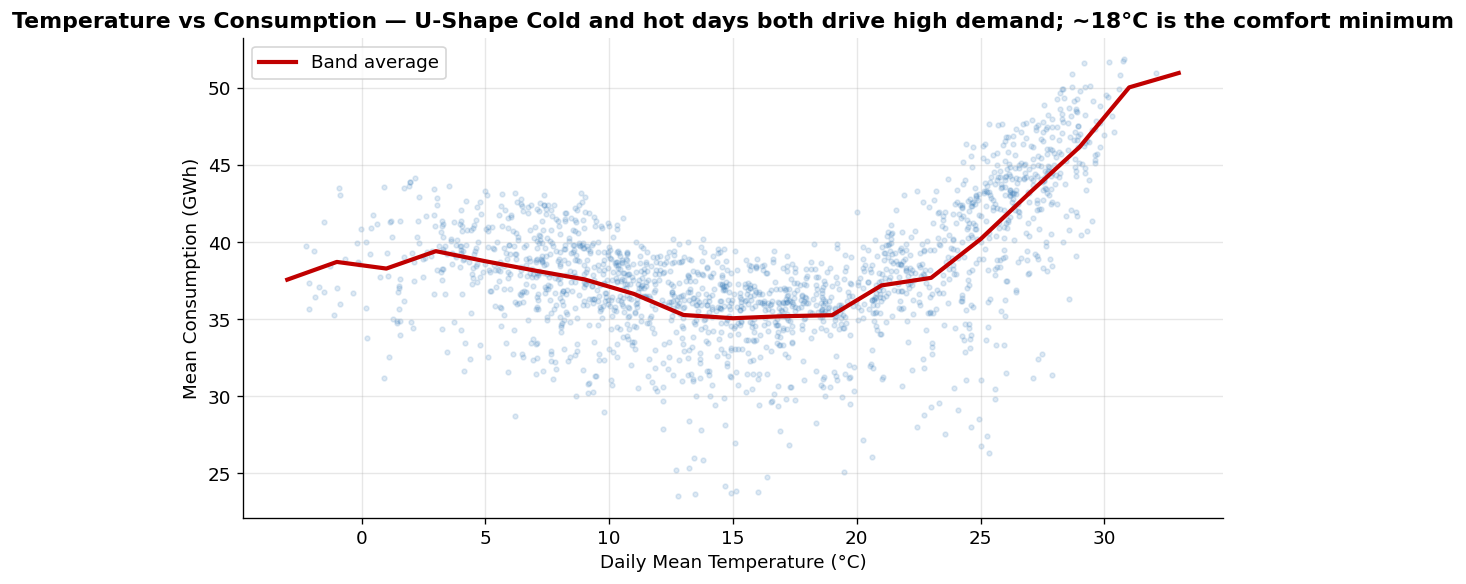

In [16]:
# Daily average consumption vs daily mean temperature
daily = df.groupby(df.index.date).agg(
    consumption=('consumption_mwh', 'mean'),
    temp=('temp_today', 'first')
).dropna()

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(daily['temp'], daily['consumption'] / 1000,
                alpha=0.15, s=8, color='#2E75B6')

# Smooth trend line using 2°C temperature bands
daily['band'] = pd.cut(daily['temp'], bins=range(-10, 45, 2))
band_avg = daily.groupby('band', observed=True)['consumption'].mean() / 1000
ax.plot([iv.mid for iv in band_avg.index], band_avg.values,
        color='#C00000', lw=2.5, zorder=5, label='Band average')

ax.set_xlabel('Daily Mean Temperature (°C)')
ax.set_ylabel('Mean Consumption (GWh)')
ax.set_title('Temperature vs Consumption — U-Shape Cold and hot days both drive high demand; ~18°C is the comfort minimum',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/p1_temp_consumption.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Feature Engineering

We build all input features from data available at time **t** (no future data used).

| Feature | Description |
|---------|-------------|
| `target_24h` | consumption at t+24 — **the prediction target** |
| `lag_1d` | consumption at t (24h before target) |
| `lag_2d` | consumption at t−24h (48h before target) |
| `lag_7d` | consumption 7 days before the target hour |
| `rolling_7d` | 7-day rolling average (recent demand level) |
| `temp_avg` | temperature at t+24 (weather forecast proxy) |
| `hour_sin / hour_cos` | cyclical hour encoding |
| `month_sin / month_cos` | cyclical month encoding |
| `is_weekend` | 1 if the predicted hour falls on a weekend |
| `is_holiday` | 1 if the predicted hour falls on a public holiday |
| `is_bayram` | 1 if the predicted hour falls on a religious festival |

In [17]:
holidays = pd.to_datetime([
    '2021-01-01','2022-01-01','2023-01-01','2024-01-01','2025-01-01',  # New Year
    '2021-04-23','2022-04-23','2023-04-23','2024-04-23','2025-04-23',  # National Sovereignty
    '2021-05-01','2022-05-01','2023-05-01','2024-05-01','2025-05-01',  # Labour Day
    '2021-05-19','2022-05-19','2023-05-19','2024-05-19','2025-05-19',  # Atatürk Day
    '2021-07-15','2022-07-15','2023-07-15','2024-07-15','2025-07-15',  # Democracy Day
    '2021-08-30','2022-08-30','2023-08-30','2024-08-30','2025-08-30',  # Victory Day
    '2021-10-29','2022-10-29','2023-10-29','2024-10-29','2025-10-29',  # Republic Day
    # Eid al-Fitr
    '2021-05-13','2021-05-14','2021-05-15','2022-05-02','2022-05-03','2022-05-04',
    '2023-04-21','2023-04-22','2023-04-23','2024-04-10','2024-04-11','2024-04-12',
    '2025-03-30','2025-03-31','2025-04-01',
    # Eid al-Adha
    '2021-07-20','2021-07-21','2021-07-22','2021-07-23',
    '2022-07-09','2022-07-10','2022-07-11','2022-07-12',
    '2023-06-28','2023-06-29','2023-06-30','2023-07-01',
    '2024-06-17','2024-06-18','2024-06-19','2024-06-20',
    '2025-06-06','2025-06-07','2025-06-08','2025-06-09',
])

bayram_dates = pd.to_datetime([
    '2021-05-13','2021-05-14','2021-05-15','2021-07-20','2021-07-21','2021-07-22','2021-07-23',
    '2022-05-02','2022-05-03','2022-05-04','2022-07-09','2022-07-10','2022-07-11','2022-07-12',
    '2023-04-21','2023-04-22','2023-04-23','2023-06-28','2023-06-29','2023-06-30','2023-07-01',
    '2024-04-10','2024-04-11','2024-04-12','2024-06-17','2024-06-18','2024-06-19','2024-06-20',
    '2025-03-30','2025-03-31','2025-04-01','2025-06-06','2025-06-07','2025-06-08','2025-06-09',
])

# Target: consumption 24 hours from now
df['target_24h'] = df['consumption_mwh'].shift(-24)

# Temperature at the predicted hour (tomorrow's daily average)
df['temp_avg'] = df['temp_today'].shift(-24)
df['temp_sq']  = df['temp_avg'] ** 2  # captures the U-shaped relationship

# Time features based on the FUTURE timestamp (the hour we're predicting)
future = df.index + pd.Timedelta(hours=24)
df['hour_sin']    = np.sin(2 * np.pi * future.hour / 24)
df['hour_cos']    = np.cos(2 * np.pi * future.hour / 24)
df['day_of_week'] = future.dayofweek
df['is_weekend']  = (future.dayofweek >= 5).astype(int)
df['month_sin']   = np.sin(2 * np.pi * future.month / 12)
df['month_cos']   = np.cos(2 * np.pi * future.month / 12)
df['year']        = future.year
df['is_holiday']  = future.normalize().isin(holidays).astype(int)
df['is_bayram']   = future.normalize().isin(bayram_dates).astype(int)

# Lag features (all from time t or earlier — no leakage)
df['lag_1d']         = df['consumption_mwh']
df['lag_2d']         = df['consumption_mwh'].shift(24)
df['lag_7d']         = df['consumption_mwh'].shift(144)
df['rolling_7d']     = df['consumption_mwh'].rolling(24 * 7).mean()
df['rolling_7d_std'] = df['consumption_mwh'].rolling(24 * 7).std()

df_clean = df.dropna(subset=['target_24h', 'lag_7d', 'rolling_7d', 'temp_avg']).copy()
df_clean.to_csv('data/df_clean.csv')

print(f'Saved: data/df_clean.csv — {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns')
print(f'Range: {df_clean.index.min().date()} → {df_clean.index.max().date()}')
df_clean[['consumption_mwh', 'target_24h', 'lag_1d', 'temp_avg', 'is_weekend', 'is_holiday']].head(4)

Saved: data/df_clean.csv — 43,657 rows, 21 columns
Range: 2021-01-07 → 2025-12-31


,consumption_mwh,target_24h,lag_1d,temp_avg,is_weekend,is_holiday
datetime,,,,,,
2021-01-07 23:00:00,36241.59,35845.08,36241.59,11.833333,0,0
2021-01-08 00:00:00,34126.16,34179.62,34126.16,11.600000,1,0
2021-01-08 01:00:00,32351.64,32540.12,32351.64,11.600000,1,0
2021-01-08 02:00:00,31140.53,31207.36,31140.53,11.600000,1,0
